# Assignment 2


## CRISP-DM

This notebook follows the CRISP-DM process model

CRISP-DM phases:

1. Business understanding: The first phase is to understand the business problem that needs to be solved. What is the goal of the analysis? What are the requirements and constraints? What is the expected outcome?

2. Data understanding: The second phase is to collect and explore the data. What data is available? What are the characteristics of the data (variable types, value distributions etc.)? Are there any quality issues with the data (missing values, outliers, nonsensical values)?

3. Data preparation: The third phase is to preprocess the data. This includes cleaning the data, transforming the data, and selecting the relevant features. These steps should be documented in such detail that they can be reproduced later.

4. Modeling: The fourth phase is to choose a machine learning method and train the model. This phase also includes the validation of the model. Documentation needs include: which method was used, which parameters were used, what was the performance of the model?

5. Evaluation: The fifth phase is to evaluate the model. How well does the model perform? Does it meet the business requirements?

6. Deployment: The final phase is to deploy the model. How will the model be used in practice? How will the results be communicated? This phase may involve creating a recommendation of how to use the model in practice, or what to do next.

## 1. Business understanding

Goal of this analysis is to demonstrate how a kNN classifier could be trained on the given dataset and used to make predictions about breast cancer diagnosis.

## 2. Data understanding

### 2.1 Description of features from data source

    "Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass.  They describe characteristics of the cell nuclei present in the image."

### 2.2 Types of features

	a) radius (mean of distances from center to points on the perimeter)
	b) texture (standard deviation of gray-scale values)
	c) perimeter
	d) area
	e) smoothness (local variation in radius lengths)
	f) compactness (perimeter^2 / area - 1.0)
	g) concavity (severity of concave portions of the contour)
	h) concave points (number of concave portions of the contour)
	i) symmetry
	j) fractal dimension ("coastline approximation" - 1)


### 2.3 List of all features
|               |               |               |
| :------------ | :-----------: | ------------: |
| ID |  	ID |  	Categorical |
| Diagnosis |   	Target |  	Categorical |
| radius1 | 	Feature | 	Continuous |
| texture1 |    	Feature | 	Continuous |
| perimeter1 |  	Feature | 	Continuous |
| area1 |   	Feature | 	Continuous |
| smoothness1 | 	Feature | 	Continuous |
| compactness1 |    	Feature | 	Continuous |
| concavity1 |  	Feature | 	Continuous |
| concave_points1 | 	Feature | 	Continuous |
| symmetry1 |   	Feature | 	Continuous |
| fractal_dimension1 |  	Feature | 	Continuous |
| radius2 | 	Feature | 	Continuous |
| texture2 |    	Feature | 	Continuous |
| perimeter2 |  	Feature | 	Continuous |
| area2 |   	Feature | 	Continuous |
| smoothness2 | 	Feature | 	Continuous |
| compactness2 |    	Feature | 	Continuous |
| concavity2 |  	Feature | 	Continuous |
| concave_points2 | 	Feature | 	Continuous |
| symmetry2 |   	Feature | 	Continuous |
| fractal_dimension2 |  	Feature | 	Continuous |
| radius3 | 	Feature | 	Continuous |
| texture3 |    	Feature | 	Continuous |
| perimeter3 |  	Feature | 	Continuous |
| area3 |   	Feature |	    Continuous |
| smoothness3 | 	Feature |	    Continuous |
| compactness3 |    	Feature |	    Continuous |
| concavity3 |  	Feature |	    Continuous |
| concave_points3 | 	Feature |	    Continuous |
| symmetry3 |   	Feature |	    Continuous |
| fractal_dimension3 |	    Feature |	    Continuous |





### 2.4 Importing the data

Features, targets, metadata and variables were imported to their own dataframes.

In [15]:
# breast cancer data is available in ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt
import itertools

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data
features : DataFrame = breast_cancer_wisconsin_diagnostic.data.features
targets : DataFrame = breast_cancer_wisconsin_diagnostic.data.targets

# metadata and variables info
metadata : DataFrame = breast_cancer_wisconsin_diagnostic.metadata
variables : DataFrame = breast_cancer_wisconsin_diagnostic.variables

### 2.5 Features Data & Datatypes

In [29]:
# example of data
features.head(2)

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


In [30]:
# only datatype is float64:
features.dtypes.unique()

array([dtype('float64')], dtype=object)

### 2.6 Variables

Notably the dataset should not have any missing variables. Variables dataframe does not specify units.

In [18]:
# variable information
variables

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Categorical,None,None,None,no
1,Diagnosis,Target,Categorical,None,None,None,no
2,radius1,Feature,Continuous,None,None,None,no
3,texture1,Feature,Continuous,None,None,None,no
4,perimeter1,Feature,Continuous,None,None,None,no
5,area1,Feature,Continuous,None,None,None,no
6,smoothness1,Feature,Continuous,None,None,None,no
7,compactness1,Feature,Continuous,None,None,None,no
8,concavity1,Feature,Continuous,None,None,None,no
9,concave_points1,Feature,Continuous,None,None,None,no


### 2.7 Data Understanding: Summary

- There are 10 different types of features
- Each data entry has these features for 3 measurement points for 30 features total
- Additional variable is Diagnosis target for 31 variables total per entry
- ID is listed as a variable but is not a column in data
- Only datatype of features is float64
- Dataset should not have missing values
- Dataset does not specify units
- All variables are continuous, except ID and Diagnosis which are categorical



### 2.8 Data Understanding: Conclusions

- Data should be standardized
- Since ID is not a column, care should be taken when deleting or sorting the data to keep features and targets list indexes equivalent.


## 3. Data Preparation

### 3.1 Standardization of data

Features were standardized with StandardScaler.

In [19]:
# confirm that no null entries actually exist
assert features.notna().all().all()
assert targets.notna().all().all()

# scale the data by standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

# this code can be used to replace Diagnosis abbreviations with other value if needed later
targets = targets.replace( {"M": "Malignant", "B": "Benign"})
assert all( value in ["Malignant","Benign"] for value in targets["Diagnosis"] )


### 3.2 Separating training and testing data

Dataset was split for a hold-out validation using train_test_split method from sklearn.

In [20]:
from sklearn.model_selection import train_test_split

# sort the features data into separate datasets for model training and testing, using scaled feature set
features_train, features_test, target_train, target_test = train_test_split(features_scaled, targets, test_size=0.25, random_state=69)

# assert the list sizes
assert len(features_train) == len(target_train) and len(features_test) == len(target_test)

### 3.3 Interpretation
Data truly did not have missing values. It is now properly standardized and splitted for training and testing.

## 4. Modeling

### 4.1 Baseline Model

Training a model without tweaking hyperparameters can be used as a baseline for comparison to other models.

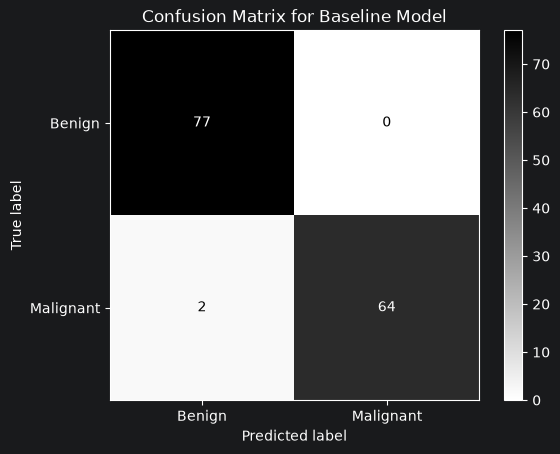

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# train the model with training data
model = KNeighborsClassifier(n_neighbors = 3)
model.fit(features_train, target_train["Diagnosis"] ) # note: target_train is not a list but a dataframe with 1 column "Diagnosis"

# use test data for test predictions
test_predictions = model.predict(features_test)

# confusion matrix of predicted class vs actual  model.classes_ returns the unique values available in target data
cm  = confusion_matrix(target_test, test_predictions, labels=model.classes_)
cmd = ConfusionMatrixDisplay(cm, display_labels=model.classes_ )

# color and style
cmd.plot(cmap=plt.cm.binary)
plt.title("Confusion Matrix for Baseline Model")
plt.show()


### 4.2 Other Models

Training k-NN models wih different hyperparameters (k)

#### 4.2.1 Optimizing Number of Neighbors

In [22]:
# task: -Train a binary classifier for predicting the cancer diagnosis (malignant / benign). Experiment with a few choices of the hyperparameter k, and report the findings.

# Define the values of k to experiment with
k_values = [1, 3, 5, 7, 9]
from sklearn.metrics import accuracy_score


results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k) # Create or Train a KNN model with k neighbors

    # train the model with training data
    model.fit(features_train, target_train["Diagnosis"])

    # use test data for test predictions 
    predictions = model.predict(features_test)

    # calculate accuracy 
    accuracy = accuracy_score( target_test["Diagnosis"], predictions)

    results.append({
        "k": k, "accuracy": accuracy
    })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

results_df

,k,accuracy
0,1,0.958042
1,3,0.986014
2,5,0.958042
3,7,0.965035
4,9,0.965035


In [23]:
# Find the best k value based on accuracy 
best_k = results_df.loc[
    results_df["accuracy"].idxmax(),
    "k"
]

best_k

np.int64(3)

### 4.2.2 Using Different Variables

Pick 1 to 4 variables for training the model and evaluate the results

In [24]:
# import itertools for creating combinations
from itertools import combinations

# list of variables to choose from
columns_copy = features_train.columns.copy()

# create combinations of 1 to 4 columns from the 30 available
columns_combinations = []
for size in range(1,5):
    columns_combinations.extend( list(itertools.combinations(columns_copy, size)) )

print("Number of combinations: ", len(columns_combinations) )

Number of combinations:  31930


In [25]:
# iterate all column combinations
for column_combination in columns_combinations:
    model = KNeighborsClassifier(n_neighbors=3)

    #filter data by columns
    filtered_training_features = features_train.filter(items=column_combination, axis="columns")
    filtered_test_features = features_test.filter(items=column_combination, axis="columns")

    # train the model with training data
    model.fit(filtered_training_features, target_train["Diagnosis"])

    # use test data for test predictions
    predictions = model.predict(filtered_test_features)

    # calculate accuracy
    accuracy = accuracy_score( target_test["Diagnosis"], predictions)

    # use same results list as before
    results.append({
        "k": column_combination, "accuracy": accuracy
    })

# Create a DataFrame from the results
results_df_column_combinations = pd.DataFrame(results)

In [26]:
# sort results by accuracy
results_df_column_combinations.sort_values(by="accuracy", axis="index", ascending=False, inplace=True)

# show full width of columns
pd.set_option('display.max_colwidth', None)

# sorted results by accuracy
results_df_column_combinations

,k,accuracy
11422,"(texture1, perimeter3, concave_points3, symmetry3)",0.986014
1,3,0.986014
11381,"(texture1, texture3, perimeter3, symmetry3)",0.979021
11362,"(texture1, radius3, smoothness3, concavity3)",0.979021
10091,"(texture1, symmetry1, radius3, concave_points3)",0.979021
...,...,...
16,"(texture2,)",0.538462
24,"(fractal_dimension2,)",0.531469
3597,"(texture2, smoothness2, symmetry2)",0.531469
301,"(texture2, smoothness2)",0.517483


### 4.2.3 Observations

Maximum accuracy the model can achieve looks to be 0.986014 and this can be reached by using only 4 variables but also by using all variables when comparing with 3 neighbors.


## 5. Evaluation

### 5.1 Evaluating using best model, with best feature combination and k value

Best Features: ('texture1', 'perimeter3', 'concave_points3', 'symmetry3')
Best k: 3
Accuracy: 0.986013986013986
Precision: 1.0
Recall: 0.9696969696969697


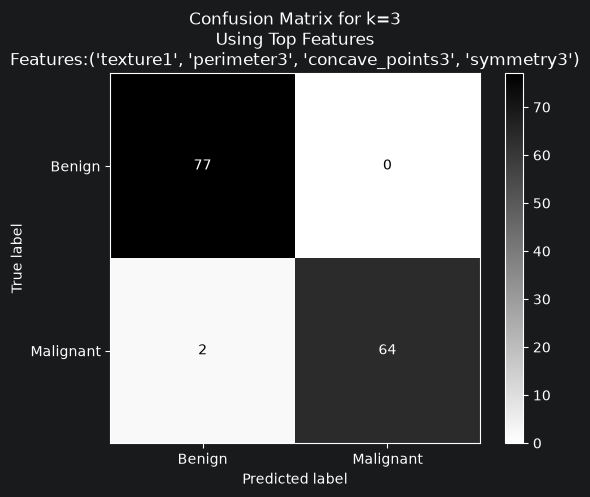

In [27]:
# Evaluate the best model 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Find best features
best_features = results_df_column_combinations.loc[
    results_df_column_combinations["accuracy"].idxmax(),
    "k"
]

# Filter datasets to use best features
filtered_features_train = features_train.filter(items=best_features, axis="columns")
filtered_features_test = features_test.filter(items=best_features, axis="columns")

# Train the best model
best_model = KNeighborsClassifier(n_neighbors=int(best_k))

# define the best model and fit it to the training data
best_model.fit(filtered_features_train, target_train["Diagnosis"])

# use test data for test predictions
final_predictions = best_model.predict(filtered_features_test)

# calculate accuracy for the best model 
accuracy = accuracy_score(target_test["Diagnosis"], final_predictions)

# calculate precision  for the best model, specifying "Malignant" as the positive class 
precision = precision_score(target_test["Diagnosis"], final_predictions, pos_label="Malignant")

# calculate recall for the best model, specifying "Malignant" as the positive class
recall = recall_score( target_test["Diagnosis"], final_predictions, pos_label="Malignant" )

print("Best Features:", best_features)
print("Best k:", best_k)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# final confusion matrix for the best model
cm = confusion_matrix(
    target_test["Diagnosis"],
    final_predictions,
    labels=best_model.classes_
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

display.plot(cmap=plt.cm.binary)
plt.title(f"Confusion Matrix for k={best_k}\nUsing Top Features\nFeatures:{best_features}")
plt.show()

The best feature combination is texture1, perimeter3, concave_points3, symmetry3.

The best value of k was 3, with an accuracy of approximately 98.6%.

The precision was 1.0, meaning that all samples predicted as malignant were actually malignant.

The recall was approximately 97.0%, meaning that the model detected most of the malignant samples. The confusion matrix shows that two malignant samples were classified as benign.

The model was evaluated using data that was not used during training.

### 5.2 Conclusion

Even though k value 3 gave us identical results as with filtered features, it is best practice to use simpler model for faster, more robust and to prevent overfitting.

## 6. Deployment

The trained kNN classifier could be used as a decision-support tool for classifying new breast cancer samples. It should not replace a medical professional. Before deployment, the model should be tested on additional data and monitored for errors, especially false negative malignant cases.